<a href="https://colab.research.google.com/github/diademsamuel/7316/blob/main/STRAIT_OF_HORMUZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
! pip install geopandas shapely requests folium

In [7]:
import geopandas as gpd
from shapely.geometry import Polygon, box
import folium
import requests
import zipfile
import io

In [17]:
# https://github.com/nvkelso/natural-earth-vector

In [18]:
import requests, zipfile, io

url = "https://github.com/nvkelso/natural-earth-vector/archive/refs/heads/master.zip"
r = requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("ne_data")

print("Natural Earth data downloaded and extracted.")


Natural Earth data downloaded and extracted.


In [19]:
import geopandas as gpd
import os

coast_path = "ne_data/natural-earth-vector-master/50m_physical/ne_50m_coastline.shp"
coast = gpd.read_file(coast_path)

coast.head()


,scalerank,featurecla,min_zoom,geometry
0,0,Coastline,1.5,"LINESTRING (180 -16.15293, 179.84814 -16.21426..."
1,0,Coastline,4.0,"LINESTRING (177.25752 -17.0542, 177.2874 -17.0..."
2,0,Coastline,4.0,"LINESTRING (127.37266 0.79131, 127.35381 0.847..."
3,0,Coastline,3.0,"LINESTRING (-81.32231 24.68506, -81.42007 24.7..."
4,0,Coastline,4.0,"LINESTRING (-80.79941 24.84629, -80.83887 24.8..."


In [20]:
from shapely.geometry import box

# Bounding box around the Strait of Hormuz
bbox = box(55.0, 24.5, 57.5, 27.5)  # (min lon, min lat, max lon, max lat)

bbox_gdf = gpd.GeoDataFrame({"name": ["Strait_BBox"]}, geometry=[bbox], crs="EPSG:4326")


In [21]:
coast_clip = gpd.clip(coast, bbox_gdf)


In [22]:
strait_polygon = bbox.difference(coast_clip.unary_union)

strait_gdf = gpd.GeoDataFrame(
    {"name": ["Strait_of_Hormuz"]},
    geometry=[strait_polygon],
    crs="EPSG:4326"
)


/tmp/ipykernel_20113/81833291.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  strait_polygon = bbox.difference(coast_clip.unary_union)


Text(0.5, 1.0, 'Delineated Strait of Hormuz (EPSG:4326)')

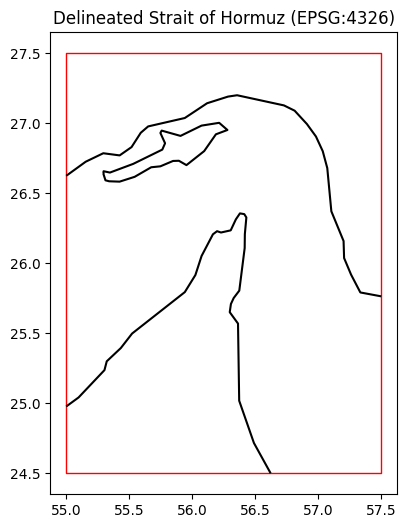

In [23]:
ax = strait_gdf.plot(edgecolor="red", facecolor="none", figsize=(6,6))
coast_clip.plot(ax=ax, color="black")
ax.set_title("Delineated Strait of Hormuz (EPSG:4326)")


Text(0.5, 1.0, 'Delineated Strait of Hormuz (EPSG:4326)')

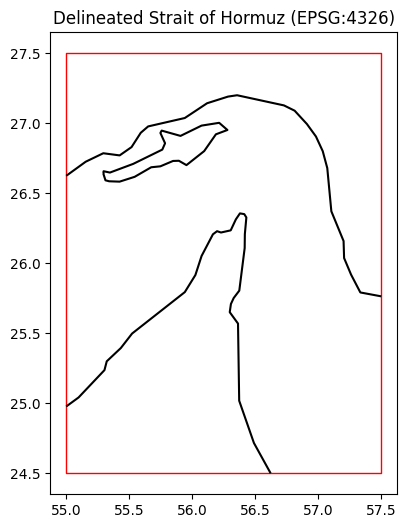

In [25]:
ax = strait_gdf.plot(edgecolor="red", facecolor="none", figsize=(6,6))
coast_clip.plot(ax=ax, color="black")
ax.set_title("Delineated Strait of Hormuz (EPSG:4326)")


In [26]:
import folium

m = folium.Map(location=[26.0, 56.0], zoom_start=7)

folium.GeoJson(
    strait_gdf.to_json(),
    name="Strait of Hormuz",
    style_function=lambda x: {"color": "red", "weight": 2, "fill": False}
).add_to(m)

m


In [27]:
import os
os.makedirs("strait_of_hormuz", exist_ok=True)

strait_gdf.to_file("strait_of_hormuz/strait_of_hormuz.geojson", driver="GeoJSON")
strait_gdf.to_file("strait_of_hormuz/strait_of_hormuz.shp", driver="ESRI Shapefile")

print("Export complete.")


Export complete.
